In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


In [2]:
df=pd.read_csv("development.csv")

In [3]:
binary_columns=['jobma_catcher_status',
                'jobma_catcher_type',
                'subscription_status',
                'jobma_login_status',
                'subscription_type',
                'referral_credit',
                'is_unlimited',
                'is_premium',
                'plan_type',
                'currency'
                ]

categorical_columns = ['company_size']

numerical_columns =['sub_user',
                    'catcher_id',
                    'wallet_sum',
                    'per_sub_user',
                    'number_of_logins',
                    'days_since_login',
                    'subscription_sum',
                    'subscription_count',
                    'premium_plan_id',
                    'pre_recorded_kit_counts',
                    'number_of_jobs_posted',
                    'number_of_invitations',
                    'number_of_pitcher_applied',
                    'pre_rec_interviews_counts',
                    'live_interviews_counts',
                    'ai_kit_counts',
                    'ai_interviews_counts'
                   ]

# Clean binary values ,
def clean_binary(X):
    return X.apply(lambda col: col.map(lambda val: 1 if pd.to_numeric(val, errors='coerce') > 0 else 0).astype(int))

def clean_categorical(X):
    return X.apply(lambda col: col.map(lambda val: str(val).strip().lower() if pd.notnull(val) else 'others'))

# Clean ordinal values
def clean_ordinal(X):
    return X.clip(lower=0)

def log_transform(X):
    X = np.asarray(X, dtype=float)
    X = np.clip(X, a_min=1e-10, a_max=None)
    return np.log(X)



#Binary pipeline
binary_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_binary, validate=False)),
                                  ('imputer', SimpleImputer(strategy='most_frequent')),
                                  ('scaler', StandardScaler())
                                 ])

#Categorical pipeline
categorical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_categorical, validate=False)),
                                       ('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                                      ])

#Ordinal pipeline
numerical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_ordinal, validate=False)),
                                   ('imputer', SimpleImputer(strategy='median')),
                                   ('log_transform', FunctionTransformer(log_transform, validate=False)),
                                   ('scaler', StandardScaler())
                                  ])

#Combined preprocessor
preprocessor = ColumnTransformer(transformers=[('bin', binary_pipeline, binary_columns),
                                               ('cat', categorical_pipeline, categorical_columns),
                                               ('ord', numerical_pipeline, numerical_columns)
                                              ] )

#pipeline
pipeline = Pipeline([('preprocessing', preprocessor)])

In [4]:
# Step 1: Fit the pipeline to your data
pipeline.fit(df)
encoder = pipeline.named_steps['preprocessing'].transformers_[1][1].named_steps['encoder']
feature_names = list(encoder.get_feature_names_out(categorical_columns))

In [5]:
feature_names

['company_size_1-25',
 'company_size_101-500',
 'company_size_26-100',
 'company_size_500-1000',
 'company_size_more than 1000']

In [6]:
columns_after_transformation = binary_columns + feature_names + numerical_columns

In [7]:
processed_df = pipeline.transform(df)

In [8]:
processed_df = pd.DataFrame(processed_df, columns=columns_after_transformation)

In [9]:
processed_df.head()

,jobma_catcher_status,jobma_catcher_type,subscription_status,jobma_login_status,subscription_type,referral_credit,is_unlimited,is_premium,plan_type,currency,...,subscription_count,premium_plan_id,pre_recorded_kit_counts,number_of_jobs_posted,number_of_invitations,number_of_pitcher_applied,pre_rec_interviews_counts,live_interviews_counts,ai_kit_counts,ai_interviews_counts
0,0.310962,0.346667,0.0,4.979493,-0.032909,-0.038007,-0.410564,1.281488,-0.870543,-0.882442,...,0.476081,0.029419,2.273266,2.920809,2.632492,3.907692,2.869721,8.267736,-0.035497,-0.023224
1,-3.215822,-2.884616,0.0,4.979493,-0.032909,-0.038007,-0.410564,1.281488,-0.870543,-0.882442,...,-0.412142,0.029419,-0.440494,-0.445020,-0.380734,-0.352914,-0.341232,-0.116898,-0.035497,-0.023224
2,0.310962,-2.884616,0.0,4.979493,-0.032909,-0.038007,-0.410564,1.281488,-0.870543,-0.882442,...,-0.412142,0.029419,-0.440494,2.160826,-0.380734,2.780409,-0.341232,-0.116898,-0.035497,-0.023224
3,0.310962,-2.884616,0.0,4.979493,-0.032909,-0.038007,-0.410564,1.281488,-0.870543,-0.882442,...,-0.412142,0.029419,-0.440494,-0.445020,-0.380734,-0.352914,-0.341232,-0.116898,-0.035497,-0.023224
4,0.310962,-2.884616,0.0,4.979493,-0.032909,-0.038007,-0.410564,1.281488,-0.870543,-0.882442,...,-0.412142,0.029419,-0.440494,2.160826,-0.380734,2.727747,-0.341232,-0.116898,-0.035497,-0.023224


In [10]:
X=df

In [11]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [12]:
X_train.shape, X_test.shape

((4436, 28), (1110, 28))

In [13]:
type(X_train), type(X_test)

(pandas.core.frame.DataFrame, pandas.core.frame.DataFrame)

In [14]:
X_train_transformed = pipeline.fit_transform(X_train)
X_test_transformed = pipeline.transform(X_test)

In [15]:
X_train_transformed.shape, X_test_transformed.shape

((4436, 32), (1110, 32))

In [16]:
X_train_transformed.shape

(4436, 32)

In [17]:
type(X_train_transformed), type(X_test_transformed)

(numpy.ndarray, numpy.ndarray)

In [18]:
type(X_train_transformed)

numpy.ndarray

In [19]:
X_df = pd.DataFrame(X_train_transformed, columns=processed_df.columns)

In [20]:
X_df.shape

(4436, 32)

In [21]:
X_train_tensor = torch.tensor(X_train_transformed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_transformed, dtype=torch.float32)

In [22]:
len(X_train_tensor), len(X_test_tensor)


(4436, 1110)

# Using Custom dataset and # DataLoder

In [23]:
class CustomDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [24]:
train_custom_dataset = CustomDataset(X_train_tensor)
test_custom_dataset = CustomDataset(X_test_tensor)

C:\Users\SSI\AppData\Local\Temp\ipykernel_18968\2659571064.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.data = torch.tensor(data, dtype=torch.float32)


In [25]:
batch_size=16
train_dataloader = DataLoader(train_custom_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_custom_dataset, batch_size=batch_size, shuffle=True)

In [26]:
len(train_custom_dataset), len(test_dataloader), len(train_custom_dataset), len(test_custom_dataset)

(4436, 70, 4436, 1110)

In [27]:
class DeepAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=64):
        super(DeepAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(),
            nn.Linear(256, 128),
            nn.LeakyReLU(),
            nn.Linear(128, latent_dim),
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 256),
            nn.LeakyReLU(),
            nn.Linear(256, input_dim),
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

In [28]:
input_dim = X_df.shape[1]
latent_dim = 64
model = DeepAutoencoder(input_dim=input_dim, latent_dim=latent_dim)
model

DeepAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=128, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=256, out_features=32, bias=True)
  )
)

# Optimizers and loss function

In [29]:
learning_rate = 0.001
epochs = 10
mse_loss_function = nn.MSELoss()
cosine_loss_function = nn.CosineEmbeddingLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-3)

In [30]:
def train_step(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               mse_loss_function:torch.nn.Module,
               cosine_loss_function:torch.nn.Module,
               optimizer:torch.optim.Optimizer
              ):
    model.train()
    epoch_total_loss = 0

    for batch_X in dataloader:
        encoded, decoded = model(batch_X)

        ''' Compute Loss '''
        mse_loss = mse_loss_function(decoded, batch_X)

        batch_size = encoded.shape[0]
        target_labels = torch.ones(batch_size)

        permuted_indices = torch.randperm(batch_size)
        encoded_shuffled = encoded[permuted_indices]

        cosine_loss = cosine_loss_function(encoded, encoded_shuffled, target_labels)
        total_loss = mse_loss + cosine_loss

        ''' BackPropagation '''
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        epoch_total_loss = total_loss.item()

    training_loss = epoch_total_loss / len(dataloader)
    return training_loss

In [31]:
def test_step(model:torch.nn.Module,
              dataloader:torch.utils.data.DataLoader,
              mse_loss_function:torch.nn.Module,
              cosine_loss_function:torch.nn.Module,
             ):

    epoch_total_loss = 0
    
    model.eval()
    with torch.inference_mode():
        for batch_X in dataloader:
            encoded, decoded = model(batch_X)  # Forward pass

            ''' Compute Loss '''
            mse_loss = mse_loss_function(decoded, batch_X)  # Reconstruction Loss
    
            batch_size = encoded.shape[0]
            target_labels = torch.ones(batch_size)

            # Compare each encoded job to another shuffled job
            permuted_indices = torch.randperm(batch_size)
            encoded_shuffled = encoded[permuted_indices]

            cosine_loss = cosine_loss_function(encoded, encoded_shuffled, target_labels)
            total_loss = mse_loss + cosine_loss
            
            epoch_total_loss += total_loss.item()

        testing_loss = epoch_total_loss / len(dataloader)
        return testing_loss

In [32]:
def evaluate(model:torch.nn.Module,
             train_dataloader:torch.utils.data.DataLoader,
             test_dataloader:torch.utils.data.DataLoader,
             mse_loss_function:torch.nn.Module,
             cosine_loss_function:torch.nn.Module,
             epochs:int = 5
            ):
    
    results = {'training_loss':[],
              'testing_loss':[]}

    for epoch in range(epochs):
        training_loss = train_step(model=model,
                                   dataloader=train_dataloader,
                                   mse_loss_function=mse_loss_function,
                                   cosine_loss_function=cosine_loss_function,
                                   optimizer=optimizer
                                  )

        testing_loss = test_step(model=model,
                                   dataloader=test_dataloader,
                                   mse_loss_function=mse_loss_function,
                                   cosine_loss_function=cosine_loss_function
                                  )

        results['training_loss'].append(training_loss)
        results['testing_loss'].append(testing_loss)

        print(f'Epoch {epoch+1}/{epochs} | Training Loss: {training_loss:.5f} | Testing Loss: {testing_loss:.5f}')

    return results

In [33]:
torch.manual_seed(42)
model_results = evaluate(model=model,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        mse_loss_function=mse_loss_function,
                        cosine_loss_function=cosine_loss_function,
                        epochs=epochs)

Epoch 1/10 | Training Loss: 0.00198 | Testing Loss: 0.70585
Epoch 2/10 | Training Loss: 0.00049 | Testing Loss: 0.58864
Epoch 3/10 | Training Loss: 0.00046 | Testing Loss: 0.55454
Epoch 4/10 | Training Loss: 0.00090 | Testing Loss: 0.49886
Epoch 5/10 | Training Loss: 0.00091 | Testing Loss: 0.48813
Epoch 6/10 | Training Loss: 0.00051 | Testing Loss: 0.41746
Epoch 7/10 | Training Loss: 0.00019 | Testing Loss: 0.39309
Epoch 8/10 | Training Loss: 0.00030 | Testing Loss: 0.37948
Epoch 9/10 | Training Loss: 0.00045 | Testing Loss: 0.38097
Epoch 10/10 | Training Loss: 0.00025 | Testing Loss: 0.43467


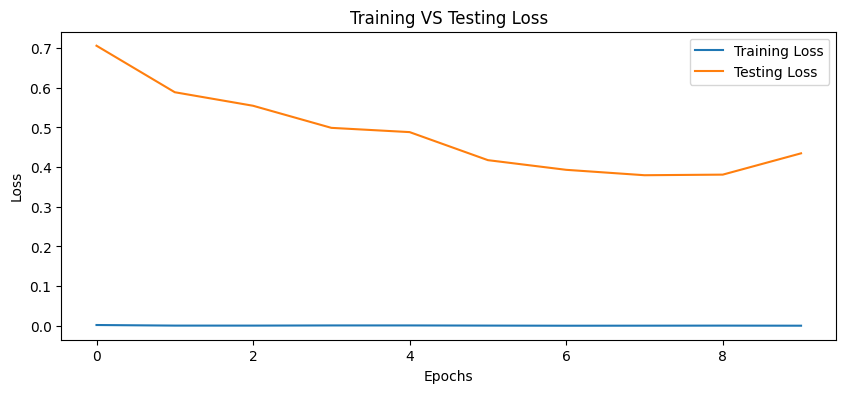

In [34]:
epochs = range(len(model_results['training_loss']))
plt.figure(figsize=(10, 4))
plt.plot(epochs, model_results['training_loss'], label='Training Loss')
plt.plot(epochs, model_results['testing_loss'], label='Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training VS Testing Loss')
plt.legend()
plt.show()

In [35]:
model.eval()
with torch.no_grad():
    all_embeddings, _ = model(torch.tensor(X_df.values, dtype=torch.float32))

In [36]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_similar_clients(user_input, all_embeddings, df_original, top_n=5):
    """
    user_input: raw user input in DataFrame format (same columns as original df)
    all_embeddings: torch.Tensor from the trained autoencoder
    df_original: the original df (with client info) to fetch results
    """
    # Preprocess user input using same pipeline
    user_input_processed = pipeline.transform(user_input)
    user_input_tensor = torch.tensor(user_input_processed, dtype=torch.float32)

    # Pass through encoder
    model.eval()
    with torch.no_grad():
        user_embedding, _ = model(user_input_tensor)

    # Compute cosine similarity
    similarity_scores = cosine_similarity(user_embedding.numpy(), all_embeddings.numpy())[0]

    # Get top N indices
    top_indices = similarity_scores.argsort()[::-1][1:top_n+1]  # [1:] to skip the input itself

    return df_original.iloc[top_indices], similarity_scores[top_indices]


In [37]:
sample_input = df.iloc[[0]]

top_clients, scores = recommend_similar_clients(sample_input, all_embeddings, df, top_n=5)
top_clients

,catcher_id,jobma_catcher_status,jobma_catcher_type,subscription_status,subscription_type,referral_credit,is_premium,sub_user,company_size,per_sub_user,...,currency,premium_plan_id,pre_recorded_kit_counts,number_of_jobs_posted,number_of_invitations,number_of_pitcher_applied,pre_rec_interviews_counts,live_interviews_counts,ai_kit_counts,ai_interviews_counts
2916,4999,0,1,1,0,0,0,1,26-100,0.0,...,1,3.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1966,3631,1,1,2,0,0,1,5,26-100,60.0,...,1,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3895,6521,1,1,2,0,0,0,1,1-25,100.0,...,0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2067,3759,1,1,2,0,0,1,100,101-500,100.0,...,0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2685,4681,1,0,2,0,0,0,100,26-100,100.0,...,0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
sample_dict = {
    'catcher_id': 1520,
    'jobma_catcher_status': 1,
    'jobma_catcher_type': 1,
    'subscription_status': 2,
    'subscription_type': 0,
    'referral_credit': 0,
    'is_premium': 1,
    'sub_user': 999,
    'company_size': '1-25',
    'per_sub_user': 100,
    'number_of_logins': 1,
    'jobma_login_status': 0,
    'days_since_login': 2304,
    'wallet_sum': 694,
    'plan_type': 0,
    'is_unlimited': 0,
    'subscription_sum': 99,
    'subscription_count': 1,
    'currency': 0,
    'premium_plan_id': 3,
    'pre_recorded_kit_counts': 7,
    'number_of_jobs_posted': 31,
    'number_of_invitations': 63,
    'number_of_pitcher_applied': 80,
    'pre_rec_interviews_counts': 61,
    'live_interviews_counts': 11,
    'ai_kit_counts': 0,
    'ai_interviews_counts': 0
}

sample_input2 = pd.DataFrame([sample_dict])

In [39]:
recommended_clients, similarity_scores = recommend_similar_clients(
    user_input=sample_input2,
    all_embeddings=all_embeddings,
    df_original=df,
    top_n=5
)
recommended_clients

,catcher_id,jobma_catcher_status,jobma_catcher_type,subscription_status,subscription_type,referral_credit,is_premium,sub_user,company_size,per_sub_user,...,currency,premium_plan_id,pre_recorded_kit_counts,number_of_jobs_posted,number_of_invitations,number_of_pitcher_applied,pre_rec_interviews_counts,live_interviews_counts,ai_kit_counts,ai_interviews_counts
1946,3608,1,1,2,0,0,1,5,26-100,60.0,...,1,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1910,3555,1,1,2,0,0,0,1,1-25,60.0,...,1,3.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2324,4163,1,1,2,0,0,0,1,101-500,60.0,...,1,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3185,5470,1,1,2,0,0,1,999,26-100,10000.0,...,1,7.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3351,5677,1,1,2,0,0,0,1,1-25,10000.0,...,1,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
sample_dict3 = { 'catcher_id': 0,
                'jobma_catcher_status': 0,
                'jobma_catcher_type': 0,
                'subscription_status': 0,
                'subscription_type': 0,
                'referral_credit': 0,
                'is_premium': 1,
                'sub_user': 0,
                'company_size': '1-25',
                'per_sub_user': 0,
                'number_of_logins': 1,
                'jobma_login_status': 0,
                'days_since_login': 0,
                'wallet_sum': 694,
                'plan_type': 0,
                'is_unlimited': 0,
                'subscription_sum': 99,
                'subscription_count': 1,
                'currency': 0,
                'premium_plan_id': 0,
                'pre_recorded_kit_counts': 0,
                'number_of_jobs_posted': 0,
                'number_of_invitations': 0,
                'number_of_pitcher_applied': 0,
                'pre_rec_interviews_counts': 0,
                'live_interviews_counts': 0,
                'ai_kit_counts': 0,
                'ai_interviews_counts': 0
              }

sample_input3 = pd.DataFrame([sample_dict])

# With Similarity score

In [41]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_similar_clients(user_input, all_embeddings, df_original, top_n=5):
    user_transformed = pipeline.transform(user_input)
    user_tensor = torch.tensor(user_transformed, dtype=torch.float32)
    with torch.no_grad():
        user_embedding, _ = model(user_tensor)
    similarities = cosine_similarity(user_embedding.numpy(), all_embeddings.numpy())[0]
    top_indices = similarities.argsort()[::-1][0:top_n+1]  # with self too
    
    # Retrieve top clients and scores
    top_clients = df_original.iloc[top_indices].copy()
    top_similarities = similarities[top_indices]
    
    # Attach similarity score to each row
    top_clients['similarity_score'] = top_similarities
    
    return top_clients

In [42]:
recommend_similar_clients(user_input=sample_input3,
                          all_embeddings=all_embeddings,
                          df_original=df,
                          top_n=5)

,catcher_id,jobma_catcher_status,jobma_catcher_type,subscription_status,subscription_type,referral_credit,is_premium,sub_user,company_size,per_sub_user,...,premium_plan_id,pre_recorded_kit_counts,number_of_jobs_posted,number_of_invitations,number_of_pitcher_applied,pre_rec_interviews_counts,live_interviews_counts,ai_kit_counts,ai_interviews_counts,similarity_score
146,581,1,0,2,0,0,1,999,1-25,100.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
1946,3608,1,1,2,0,0,1,5,26-100,60.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.999999
1910,3555,1,1,2,0,0,0,1,1-25,60.0,...,3.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.999999
2324,4163,1,1,2,0,0,0,1,101-500,60.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.999998
3185,5470,1,1,2,0,0,1,999,26-100,10000.0,...,7.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.999996
3351,5677,1,1,2,0,0,0,1,1-25,10000.0,...,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.999993
